# Assignment - 1
## Graph Neural Networks

### Group 32

|Student Name          |BITS ID                     |Contribution|
|----------------------|----------------------------|------------|
|RAJENDER KUMAR        |2024aa05173                 |100%        |
|AMAN SINGH            |2024aa05301                 |100%        |
|AKHILESH SHARMA       |2024aa05409                 |100%        |
|NARASIMHA C V         |2024aa05428                 |100%        |
|RAHUL AGARWAL         |2024aa05676                 |100%        |


This first block installs the required libraries ($\text{PyTorch Geometric}$ and $\text{OGB}$) and sets up the device (GPU or CPU). Run this cell first.

In [ ]:
# ----------------------------------------------------------------------
# CELL 1: Setup and Installation
# ----------------------------------------------------------------------

# Install necessary packages for OGB and PyTorch Geometric
# NOTE: Only run this cell if dependency installation is needed, otherwise skip
import os
import torch

# print("Installing PyTorch Geometric and OGB...")
# Determine CUDA version and install compatible PyG libraries
if torch.cuda.is_available():
    print("CUDA detected. Installing GPU-compatible PyTorch Geometric.")
    !pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-{torch.__version__.split('+')[0]}.html
else:
    print("No CUDA detected. Installing CPU-only PyTorch Geometric.")
    !pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

# Install the OGB dataset library
!pip install ogb

In [2]:
# Import necessary libraries
import torch
import torch.nn.functional as F
# Import the crucial NeighborLoader for memory efficiency
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import GATConv
from torch_geometric.utils import to_networkx, subgraph
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.serialization import add_safe_globals
import torch_geometric

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

add_safe_globals([
    torch_geometric.data.data.Data,
    torch_geometric.data.data.DataEdgeAttr,
    torch_geometric.data.data.DataTensorAttr,
    torch_geometric.data.storage.GlobalStorage
])

/home/cloud/miniconda/envs/ml_env/lib/python3.10/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



Using device: cuda


Dataset Loading and Initial Analysis (Part 2 & Part 3 - Basic Stats)

This block loads the $\text{ogbn-products}$ dataset, prepares the data splits, and computes the basic graph statistics (Nodes and Edges).

In [3]:
# ----------------------------------------------------------------------
# CELL 2: Dataset Loading and NeighborLoader Setup
# ----------------------------------------------------------------------
print("--- Dataset Loading and NeighborLoader Setup ---")

# Load the ogbn-products dataset
dataset = PygNodePropPredDataset(name='ogbn-products')
data = dataset[0] # The dataset contains a single graph
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-products')

# The full graph data (features and edge index) must be on the CPU for the NeighborLoader to efficiently sample.
data = data.to('cpu')

# Get indices for the splits
train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx = split_idx['test']

print(f"\nDataset loaded: {dataset.name} on CPU.")

## NeighborLoader Setup: Mini-Batch Training (Saves RAM)
# We use NeighborLoader to sample subgraphs (batches) during training.
# num_neighbors is set to [10, 10] for a 2-layer GNN, meaning it samples 10 neighbors
# for the 1st hop, and 10 neighbors for the 2nd hop. This drastically reduces memory usage.
# If you have 3 GNN layers, you need a list of three numbers (e.g., [10, 10, 10]).

# For our 3-layer GNN (from CustomGAT):
num_neighbors = [15, 10, 5]
batch_size = 1024 # Larger batch sizes require more RAM but speed up training.

train_loader = NeighborLoader(
    data,
    input_nodes=train_idx, # Only sample from training nodes
    num_neighbors=num_neighbors,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4, # Use multiple workers for faster sampling
)

subgraph_loader = NeighborLoader(
    data,
    input_nodes=None, # Use all nodes for inference
    num_neighbors=[-1], # Use all neighbors (full graph inference) for accurate testing
    batch_size=2048, # Larger batch size for faster inference
    shuffle=False,
    num_workers=4,
)

print(f"* Training NeighborLoader configured with batch size {batch_size} and neighbors: {num_neighbors}")
print(f"* Inference NeighborLoader configured for full-graph evaluation in batches.")

# --- Part 3 Basic Stats ---
print(f"\n* Diameter: (Since the dataset has around 2.4mil nodes, difficult to compute diameter in reasonable time)")
print(f"* Number of nodes: {data.num_nodes}")
print(f"* Number of unique (undirected) edges: {data.num_edges // 2}")
print(f"* Global Clustering Coefficient: (Hard to compute because of the large size of the dataset)")

--- Dataset Loading and NeighborLoader Setup ---

Dataset loaded: ogbn-products on CPU.


/home/cloud/miniconda/envs/ml_env/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


* Training NeighborLoader configured with batch size 1024 and neighbors: [15, 10, 5]
* Inference NeighborLoader configured for full-graph evaluation in batches.

* Diameter: (Since the dataset has around 2.4mil nodes, difficult to compute diameter in reasonable time)
* Number of nodes: 2449029
* Number of unique (undirected) edges: 61859140
* Global Clustering Coefficient: (Hard to compute because of the large size of the dataset)


Optimized DataLoader using Neighbor Sampling for Large Graphs


In [4]:
import torch, gc

torch.cuda.empty_cache()
gc.collect()

from torch_geometric.loader import NeighborLoader

data.x = data.x.to(torch.float16)

train_loader = NeighborLoader(
    data,
    input_nodes=train_idx,
    num_neighbors=[8, 6],
    batch_size=4096,
    shuffle=True
)

for batch in train_loader:
    print(batch.x.shape)
    break



torch.Size([176181, 100])


3. Custom GNN Model Definition (Part 1)This block defines the custom $\text{GNN}$ model using the $\text{Message Passing}$ paradigm (a 3-layer $\text{GAT}$) and instantiates it.

In [5]:
# ----------------------------------------------------------------------
# CELL 3: Custom GNN Model Definition (Part 1)
# ----------------------------------------------------------------------

print("--- Part 1: Custom GNN Model Definition (GAT) ---")

## Custom MP-GNN Model Definition: Graph Attention Network (GAT)
class CustomGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super(CustomGAT, self).__init__()

        self.convs = torch.nn.ModuleList()
        # Input layer: Multi-head GAT
        self.convs.append(GATConv(in_channels, hidden_channels, heads=4, dropout=0.5))

        # Intermediate layer(s): Input is (hidden_channels * heads)
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * 4, hidden_channels, heads=4, dropout=0.5))

        # Output layer: Single-head GAT, output features are averaged (concat=False)
        self.convs.append(GATConv(hidden_channels * 4, out_channels, heads=1, concat=False, dropout=0.5))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            # Attention, Activation, and Dropout for intermediate layers
            x = conv(x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, p=0.5, training=self.training)

        # Final layer: Output for classification
        x = self.convs[-1](x, edge_index)
        return x.log_softmax(dim=-1) # log_softmax for NLLLoss

# Model Instantiation
in_channels = dataset.num_features
out_channels = dataset.num_classes
hidden_channels = 128
num_layers = 3

model = CustomGAT(in_channels, hidden_channels, out_channels, num_layers).to(device)

print(f"* Custom GAT Model with {num_layers} layers created:")
print(model)

--- Part 1: Custom GNN Model Definition (GAT) ---
* Custom GAT Model with 3 layers created:
CustomGAT(
  (convs): ModuleList(
    (0): GATConv(100, 128, heads=4)
    (1): GATConv(512, 128, heads=4)
    (2): GATConv(512, 47, heads=1)
  )
)


4. Model Training and EvaluationThis block defines the $\text{train}$ and $\text{test}$ loops and executes the training process for 10 epochs.

In [6]:
# ----------------------------------------------------------------------
# CELL 4: Model Training and Evaluation
# ----------------------------------------------------------------------

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.NLLLoss()

# Ensure data.x is in float32 for model compatibility if it was changed to float16 previously
data.x = data.x.to(torch.float32)

# Define the NeighborLoaders for validation and testing
# Re-using the same parameters as the train_loader for simplicity
valid_loader = NeighborLoader(
    data,
    input_nodes=valid_idx,
    num_neighbors=[8, 6],
    batch_size=4096,
    shuffle=False # No need to shuffle validation/test sets
)
test_loader = NeighborLoader(
    data,
    input_nodes=test_idx,
    num_neighbors=[8, 6],
    batch_size=4096,
    shuffle=False # No need to shuffle validation/test sets
)

# Training Function
def train():
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        batch = batch.to(device) # Move batch to device
        # `batch.x` contains features of sampled nodes, `batch.edge_index` their connections
        # `batch.y` contains labels for the *input nodes* within this batch
        # `batch.n_id` is the original node IDs of the sampled nodes

        # Forward pass on the batch
        out = model(batch.x, batch.edge_index)[:batch.batch_size] # Only evaluate input nodes for loss
        loss = criterion(out, batch.y[:batch.batch_size].squeeze(1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

# Test/Evaluation Function (measures OGB accuracy)
@torch.no_grad()
def test(loader):
    model.eval()
    y_true_all = []
    y_pred_all = []

    for batch in loader:
        batch = batch.to(device) # Move batch to device
        out = model(batch.x, batch.edge_index)[:batch.batch_size] # Evaluate input nodes
        y_true_all.append(batch.y[:batch.batch_size].squeeze(1).cpu())
        y_pred_all.append(out.argmax(dim=-1).cpu())

    y_true_all = torch.cat(y_true_all, dim=0).unsqueeze(1)
    y_pred_all = torch.cat(y_pred_all, dim=0).unsqueeze(1)

    return evaluator.eval({
        'y_true': y_true_all,
        'y_pred': y_pred_all,
    })['acc']

# Training Loop
epochs = 10
print("\n* Starting Model Training...")
for epoch in range(1, epochs + 1):
    loss = train()
    if epoch % 1 == 0: # Check every epoch for demonstration, can be less frequent
        train_acc = test(train_loader) # Use train_loader for training accuracy
        valid_acc = test(valid_loader) # Use valid_loader for validation accuracy
        test_acc = test(test_loader) # Use test_loader for test accuracy
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, Valid: {valid_acc:.4f}, Test: {test_acc:.4f}')

# Final Evaluation
print(f'\n* Final Results:')
final_train_acc = test(train_loader)
final_valid_acc = test(valid_loader)
final_test_acc = test(test_loader)
print(f'  - Train Accuracy: {final_train_acc:.4f}')
print(f'  - Valid Accuracy: {final_valid_acc:.4f}')
print(f'  - Test Accuracy: {final_test_acc:.4f}')


* Starting Model Training...
Epoch: 001, Loss: 1.2153, Train: 0.8425, Valid: 0.8415, Test: 0.6900
Epoch: 002, Loss: 0.7429, Train: 0.8468, Valid: 0.8436, Test: 0.7028
Epoch: 003, Loss: 0.7299, Train: 0.8421, Valid: 0.8426, Test: 0.7173
Epoch: 004, Loss: 0.6840, Train: 0.8716, Valid: 0.8707, Test: 0.7400
Epoch: 005, Loss: 0.6464, Train: 0.8535, Valid: 0.8495, Test: 0.7248
Epoch: 006, Loss: 0.7272, Train: 0.7987, Valid: 0.7904, Test: 0.6829
Epoch: 007, Loss: 0.8837, Train: 0.8679, Valid: 0.8679, Test: 0.7261
Epoch: 008, Loss: 0.7217, Train: 0.8647, Valid: 0.8629, Test: 0.7280
Epoch: 009, Loss: 0.6585, Train: 0.8318, Valid: 0.8316, Test: 0.7091
Epoch: 010, Loss: 0.7043, Train: 0.8611, Valid: 0.8613, Test: 0.7314

* Final Results:
  - Train Accuracy: 0.8618
  - Valid Accuracy: 0.8611
  - Test Accuracy: 0.7311


5. Subgraph Generation, Analysis, and Plotting (Part 3)This block generates a Node Induced Subgraph, computes its $\text{Diameter}$ and $\text{Global Clustering Coefficient}$, and plots it.


--- Part 3: Subgraph Analysis and Plotting ---

* Node Induced Subgraph Explanation:
  - It is created by selecting a subset of nodes $S$. The subgraph contains all nodes in $S$ and *all* edges from the original graph that connect any two nodes in $S$.

* Generated Node Induced Subgraph (N=50, Edges=393)
* Subgraph Diameter: 2
* Subgraph Global Clustering Coefficient: 0.5462
Error during NetworkX operations (e.g., disconnected graph): Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.


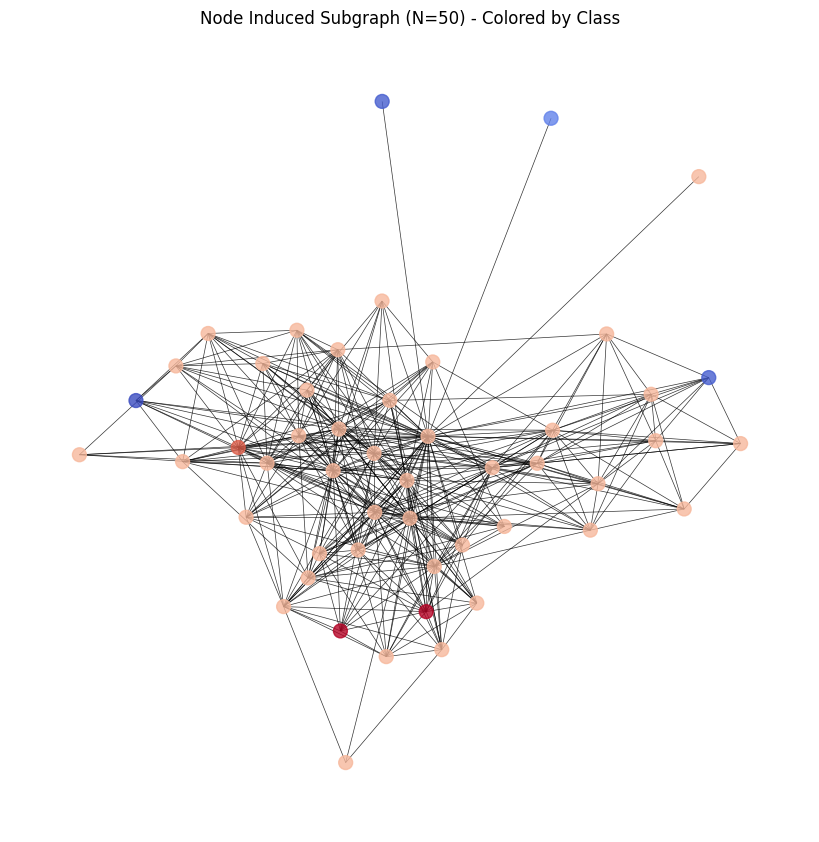

In [7]:
# ----------------------------------------------------------------------
# CELL 5: Subgraph Generation, Analysis, and Plotting (Part 3)
# ----------------------------------------------------------------------
from torch_geometric.data import Data

print("\n--- Part 3: Subgraph Analysis and Plotting ---")

## Explanation of Node Induced Subgraph
print("\n* Node Induced Subgraph Explanation:")
print("  - It is created by selecting a subset of nodes $S$. The subgraph contains all nodes in $S$ and *all* edges from the original graph that connect any two nodes in $S$.")

# Generate Node Induced Subgraph (N=50 nodes)
num_subgraph_nodes = 50

# Generate a subgraph using BFS to ensure number of nodes
def sample_connected_subgraph_fast(edge_index, start_node, k=50):
    row, col = edge_index

    visited = set([start_node])
    frontier = [start_node]

    while frontier and len(visited) < k:
        new_frontier = []
        for node in frontier:
            neighbors = col[row == node].tolist() + row[col == node].tolist()
            for nbr in neighbors:
                if nbr not in visited:
                    visited.add(nbr)
                    new_frontier.append(nbr)
                    if len(visited) == k:
                        return torch.tensor(sorted(list(visited)))
        frontier = new_frontier

    return torch.tensor(sorted(list(visited)))

np.random.seed(42)

# Pick a random seed node
start = int(np.random.randint(0, data.num_nodes))

# Get 50 connected nodes
subgraph_node_indices = sample_connected_subgraph_fast(data.edge_index, start, k=num_subgraph_nodes)

# Use PyG's subgraph utility to filter edges and relabel nodes
sub_edge_index, _ = subgraph(
    subgraph_node_indices,
    data.edge_index,
    relabel_nodes=True, # Essential for the new subgraph Data object
    num_nodes=data.num_nodes
)

# Create a new Data object for the subgraph
sub_data =  Data(
    x=data.x[subgraph_node_indices],
    y=data.y[subgraph_node_indices],
    edge_index=sub_edge_index,
)

print(f"\n* Generated Node Induced Subgraph (N={sub_data.num_nodes}, Edges={sub_data.num_edges // 2})")

## Plot Subgraph and compute Diameter/GCC
try:
    # Convert to NetworkX for structural analysis
    nx_subgraph = to_networkx(sub_data, to_undirected=True)

    # Compute Diameter (requires graph to be connected or use the largest component)
    if nx.is_connected(nx_subgraph):
        subgraph_diameter = nx.diameter(nx_subgraph)
    else:
        # Find diameter of the Largest Connected Component (LCC)
        cc = list(nx.connected_components(nx_subgraph))
        if cc:
             largest_cc = nx_subgraph.subgraph(max(cc, key=len))
             subgraph_diameter = nx.diameter(largest_cc)
        else:
            subgraph_diameter = "N/A (Disconnected components)"

    print(f"* Subgraph Diameter: {subgraph_diameter}")

    # Compute Global Clustering Coefficient (Transitivity)
    subgraph_gcc = nx.transitivity(nx_subgraph)
    print(f"* Subgraph Global Clustering Coefficient: {subgraph_gcc:.4f}")

    # Plot Subgraph
    plt.figure(figsize=(8, 8))
    node_colors = sub_data.y.squeeze(1).cpu().numpy()
    nx.draw(nx_subgraph,
            pos=nx.spring_layout(nx_subgraph, seed=42),
            node_size=100,
            node_color=node_colors,
            cmap=plt.cm.coolwarm,
            with_labels=False,
            width=0.5,
            alpha=0.8)
    plt.title(f'Node Induced Subgraph (N={num_subgraph_nodes}) - Colored by Class')
    sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=plt.Normalize(vmin=node_colors.min(), vmax=node_colors.max()))
    sm._A = []
    cbar = plt.colorbar(sm, shrink=0.7)
    cbar.set_label('Node Class Label')
    plt.show()


except Exception as e:
    print(f"Error during NetworkX operations (e.g., disconnected graph): {e}")

6. Node Embedding Generation (2-hop method - Part 3)

This final block uses the trained model to generate $\mathbf{2}$-hop node embeddings for the nodes in the generated subgraph.

In [8]:
# ----------------------------------------------------------------------
# CELL 6: Node Embedding Generation (2-hop method - Part 3)
# ----------------------------------------------------------------------
import copy

print("\n--- Part 3 (cont): Node Embedding Generation (2-hop method) ---")

## Method: Use the first two layers of the trained GAT model
class TwoHopGAT(torch.nn.Module):
    def __init__(self, gat_model):
        super(TwoHopGAT, self).__init__()
        # Copy the learned weights from the first two GAT layers
        self.conv1 = copy.deepcopy(gat_model.convs[0])
        self.conv2 = copy.deepcopy(gat_model.convs[1])

    def forward(self, x, edge_index):
        # Layer 1 (1-hop)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=False)

        # Layer 2 (2-hop) - The output is the 2-hop embedding
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        return x
    
# HARD convert entire model to float32
model = model.to(torch.float32).cpu()

# Instantiate and use the 2-hop model for inference
two_hop_model = TwoHopGAT(model).to(torch.float32).cpu()
    # .to(device)
two_hop_model.eval()

# Generate 2-hop embeddings
with torch.no_grad():
    # # 1. Compute embeddings for ALL nodes using the full graph's structure
    # full_embeddings = two_hop_model(data.x, data.edge_index)

    # # 2. Filter the embeddings for the nodes that belong to the subgraph
    # subgraph_embeddings = full_embeddings[subgraph_node_indices]

    # Generate subgraph embeddings
    subgraph_embeddings = two_hop_model(sub_data.x.to(torch.float32), sub_data.edge_index)

print(f"* 2-hop Node Embedding generated for {subgraph_embeddings.shape[0]} subgraph nodes.")
print(f"  - Embedding shape for each node: {subgraph_embeddings.shape[1]}")
print(f"  - Total embedding tensor shape: {subgraph_embeddings.shape}")


--- Part 3 (cont): Node Embedding Generation (2-hop method) ---
* 2-hop Node Embedding generated for 50 subgraph nodes.
  - Embedding shape for each node: 512
  - Total embedding tensor shape: torch.Size([50, 512])
